# Ingredient optimization project 

For the homework assignment during an interview process, the task was to optimize a cell growth media formulation. The media can consist of 30 different ingredients that can potentially support cell growth. Two main objectives are to simplify the formulation by reducing the number of ingredients and maximizing the growth rate as well as morphology why minimizing the cost. 

Reducing the number if ingredients reduces the complexity of the suppy chain, accelerates the optimization process by reducing the space of solution and can lead to cost savings.

Data from an initial, random screeening are available in `data/raw_data.xlsx`. 

## Data exploration & ingredient selection

Start by determining which are the key ingredients impacting the target variables growth rate and morphology. For this, first explore the data and identify possible missing values or anomalies

### Data exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

We start by loading in the Excel sheet. It has 40 columns with 939 entries each. 

In [2]:
# import and view data
raw_data = pd.read_excel('.\data/raw_data.xlsx', sheet_name='Sheet1')
raw_data.head()

,experimental_condition_id,formulation_id,cell_batch_id,microplate_barcode,well_loc,ING_1,ING_2,ING_3,ING_4,ING_5,...,ING_26,ING_27,ING_28,ING_29,ING_30,ING_FBS,[CHAR]initial_cell_count,[CHAR]growth_rate (h^-1),[CHAR]growth_rate_R_sq,[CHAR]Morphology_AVG
0,cb808a4a-776d-42d2-9f28-3e889bb788e7,5d6451bb-26c3-43f6-8a15-03b7a3040374,537a7487-9065-417d-a539-5c5b838c3bbf,MUL-ASY-HUN5Z6,F1,0.112675,0.021649,0.007654,0.005265,0.019563,...,1.763543,0.001256,0.000952,0.060166,0.000008,0,1664,0.149789,0.747844,0.341139
1,3d9cd8f3-fca0-4685-96aa-3f395ada1fda,d9501620-3003-4583-9661-401d47fe1a52,537a7487-9065-417d-a539-5c5b838c3bbf,MUL-ASY-FH1YLW,F4,0.005074,0.012839,0.030591,0.060176,0.052490,...,0.105003,0.001558,0.001773,0.042960,0.000002,0,2131,0.140185,0.737760,0.300750
2,3d9cd8f3-fca0-4685-96aa-3f395ada1fda,d9501620-3003-4583-9661-401d47fe1a52,7696c5d0-511b-45cb-a697-e12cb4677058,MUL-ASY-BA8WHH,F4,0.005074,0.012839,0.030591,0.060176,0.052490,...,0.105003,0.001558,0.001773,0.042960,0.000002,0,1429,0.112516,0.783015,0.270316
3,ede7d04c-bcac-4de8-8fd0-618653a9bc7f,a6cc90b9-2711-446e-b12f-c3d630463849,7696c5d0-511b-45cb-a697-e12cb4677058,MUL-ASY-BA8WHH,A4,0.076216,0.003586,0.062407,0.071191,0.009489,...,0.414396,0.001902,0.001463,0.081094,0.000009,0,1615,0.049130,0.924334,0.238477
4,ede7d04c-bcac-4de8-8fd0-618653a9bc7f,a6cc90b9-2711-446e-b12f-c3d630463849,537a7487-9065-417d-a539-5c5b838c3bbf,MUL-ASY-FH1YLW,A4,0.076216,0.003586,0.062407,0.071191,0.009489,...,0.414396,0.001902,0.001463,0.081094,0.000009,0,2949,0.060477,0.825284,0.372411


Next, we check if there are any missing values in the table, e.g., if some cells contain values which are not filled or not a number. As can be seen below, this is not the case.

In [3]:
# check if there are missing values in any column
raw_data.isnull().any().any()

False

Next, let's see if there are any anomalies or outliers. To do so, we use the Interquartile Range ($IQR$). This measure of statistical dispersion is defined as the range within which 50% of the data falls. To calculate it, we compute the difference between the third quartile $Q3$, which contains 75% of the data, and the first quartile $Q1$ containing 25% of the data. 

Based on the $IQR$ we can define lower- and upper bounds: 

\begin{align}
    \text{lower bound} &= Q1 - 1.5 \cdot IQR\,, \\
    \text{upper bound} &= Q3 + 1.5 \cdot IQR\,.\\
\end{align}

Values that are outside these bounds are much lower or higher than the majority of the dataset and are therefore considered outliers. Here, we choose to use the $IQR$ because it does not assume any underlying distribution for the variables. We could make the constraint for outliers more strict or more loose by decreasing or increasing the factor 1.5 in the above formula.

In [4]:
print('Identifying outliers using Interquantile Range (IQR):')

outliers_tot = list(np.zeros(len(raw_data)))

# loop over all columns containing numeric values
for k in raw_data.columns[5:]:
    
    df = raw_data[k]
    
    # determine first and third quartile
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    
    # compute IQR
    IQR = q3 - q1
    factor = 1.5
    
    # compute upper and lower limits 
    lower_limit = q1 - (IQR * factor)
    upper_limit = q3 + (IQR * factor)
    
    # determine number of values outside of above determined bounds
    outliers = (df < lower_limit) + (df > upper_limit)
    num_outliers = outliers.sum()
    outliers_tot += outliers
    
    # print column name if there are outliers 
    if num_outliers > 0: 
        print('\tColumn', k, 'has', num_outliers,  'outliers.')

Identifying outliers using Interquantile Range (IQR):
	Column [CHAR]initial_cell_count has 90 outliers.
	Column [CHAR]Morphology_AVG has 8 outliers.


It seems there are two columns with outliers; the column with the initial cell count as well as the column with morphology. Let's look at the distributions of the columns in more detail and compare them to the computed quartiles and lower or upper limits.

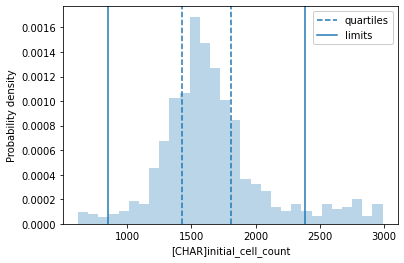

In [5]:
k = '[CHAR]initial_cell_count'

df = raw_data[k]

# determine first and third quartile
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)#

# compute IQR
IQR = q3 - q1
factor = 1.5

# compute upper and lower limits 
lower_limit = q1 - (IQR * factor)
upper_limit = q3 + (IQR * factor)

# plot distribution in that column
_ = plt.hist(df, bins=30, alpha = 0.3, density=True)

# plot first and third quartile
plt.axvline(q1, ls='dashed', label='quartiles')
plt.axvline(q3, ls='dashed')

# plot upper and lower limits based on the IQR
plt.axvline(lower_limit, label='limits')
plt.axvline(upper_limit)

plt.legend(framealpha=1.0)
plt.xlabel(k)
plt.ylabel('Probability density');

Part of these outliers might be due to measurement errors. Since our dataset is sufficiently large, we remove the outliers.

In [6]:
# drop columns with outliers
data = raw_data.drop([i for i,o in enumerate(outliers_tot) if o > 0])

Check if there are any logical outliers, i.e., values where any of the variables are negative. Since they are concentrations, cell counts or a measure of the morphologhy between 0 and 1 they should not be negative: 

In [7]:
(data.iloc[:,5:] < 0).any().any()

False

Check if there are any experiments where the R squared value representing the fitness of the logistic growth model to the cell count data is too small so that we cannot use the corresponding data for the estimated cell growth. 

In [8]:
data['[CHAR]growth_rate_R_sq'].min()

0.67172298

The minimum value we find is still quite reasonable so that we can keep all data.

Next, we take a look at the data to check if we see any weird distributions by plotting the values as a function of their index. While most of the columns are randomly distributed (left) some have more structure probably because of the experiment schedule (right). Since these are in-variable correlations we do not need to worry about these structures.

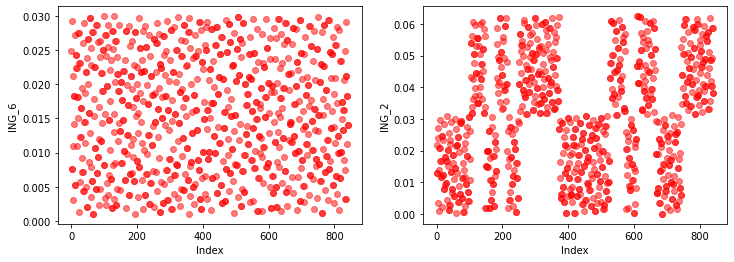

In [10]:
# indices of each experiment
integers = range(len(data))

plt.figure(figsize=(12, 4))

# plot data in columns as function of indices
plt.subplot(1,2,1)
plt.scatter(integers, data[data.columns[10]], c='red', alpha=0.5)
plt.xlabel('Index')
plt.ylabel(data.columns[10])

plt.subplot(1,2,2)
plt.scatter(integers, data[data.columns[6]], c='red', alpha=0.5)
plt.xlabel('Index')
plt.ylabel(data.columns[6]);

For further illustration we can also print descriptive statistics such as the mean and the standard deviation of each column: 

In [11]:
# calculate mean and standard deviation
means = data.iloc[:,5:].mean()
std_devs = data.iloc[:,5:].std()

# create a new dataframe from means and standard deviations
summary_df = pd.DataFrame({
    'mean': means,
    'standard deviation': std_devs
})

# format dataframe to use 7 decimal places instead of scientific notation
summary_df_formatted = summary_df.applymap(lambda x: f"{x:.7f}")
print("\nSummary dataframe formatted to 7 decimal places:\n", summary_df_formatted)


Summary dataframe formatted to 7 decimal places:
                                   mean standard deviation
ING_1                        0.0623554          0.0359652
ING_2                        0.0301428          0.0179768
ING_3                        0.0313526          0.0179742
ING_4                        0.0616963          0.0363728
ING_5                        0.0311533          0.0178755
ING_6                        0.0154637          0.0083368
ING_7                        0.0509023          0.0280048
ING_8                        0.5502200          0.2616266
ING_9                        0.5506693          0.2590447
ING_10                       0.0000500          0.0000288
ING_11                       0.0000051          0.0000028
ING_12                       0.0000497          0.0000292
ING_13                       0.0000506          0.0000287
ING_14                       0.0000498          0.0000287
ING_15                       0.0000005          0.0000003
ING_16               

From this we can observe that the column `ING_FBS` has zero standard deviation, because all entries in the column are zero. Accordingly, the column does not contain any information and we will remove it for the further analysis to determine the most relevant ingredients for cell growth and morphology. This of course assumes that the concentration of Fetal Bovine Serum will be zero in all future experiments. The variance of the other columns seems reasonable compared to the respective means. 

In [12]:
# remove zero variance column
data = data.drop('ING_FBS', axis=1)

Check if there are any duplicates: 

In [13]:
data.nunique()

experimental_condition_id    576
formulation_id               576
cell_batch_id                  2
microplate_barcode            34
well_loc                      32
ING_1                        576
ING_2                        576
ING_3                        576
ING_4                        576
ING_5                        576
ING_6                        576
ING_7                        576
ING_8                        576
ING_9                        576
ING_10                       534
ING_11                       546
ING_12                       551
ING_13                       533
ING_14                       538
ING_15                       541
ING_16                       511
ING_17                       525
ING_18                       541
ING_19                       550
ING_20                       444
ING_21                       472
ING_22                       457
ING_23                       375
ING_24                       576
ING_25                       576
ING_26    

It appears there are many duplicates in the ingredient concentrations. However, the growth rate and morphology are unique for each entry: 

In [14]:
data.duplicated().any()

False

Let's take a look at entries that have the same experimental condition. It appears that the same experiment with the same ingredient composition was carried out multiple times. However, they vary in in the initial cell counts as well as in the growth rate and morphology. 

In [15]:
data.loc[data['experimental_condition_id'].duplicated(keep=False) == True][:5]

,experimental_condition_id,formulation_id,cell_batch_id,microplate_barcode,well_loc,ING_1,ING_2,ING_3,ING_4,ING_5,...,ING_25,ING_26,ING_27,ING_28,ING_29,ING_30,[CHAR]initial_cell_count,[CHAR]growth_rate (h^-1),[CHAR]growth_rate_R_sq,[CHAR]Morphology_AVG
1,3d9cd8f3-fca0-4685-96aa-3f395ada1fda,d9501620-3003-4583-9661-401d47fe1a52,537a7487-9065-417d-a539-5c5b838c3bbf,MUL-ASY-FH1YLW,F4,0.005074,0.012839,0.030591,0.060176,0.052490,...,0.146565,0.105003,0.001558,0.001773,0.042960,0.000002,2131,0.140185,0.737760,0.300750
2,3d9cd8f3-fca0-4685-96aa-3f395ada1fda,d9501620-3003-4583-9661-401d47fe1a52,7696c5d0-511b-45cb-a697-e12cb4677058,MUL-ASY-BA8WHH,F4,0.005074,0.012839,0.030591,0.060176,0.052490,...,0.146565,0.105003,0.001558,0.001773,0.042960,0.000002,1429,0.112516,0.783015,0.270316
10,041266b5-e832-4e21-a47d-cfc737f3a684,b5e7799f-bffc-4ee2-bd8a-3627351b5638,537a7487-9065-417d-a539-5c5b838c3bbf,MUL-ASY-8148U7,B10,0.034342,0.020782,0.020669,0.031288,0.015433,...,0.197391,1.900811,0.000090,0.001179,0.111029,0.000006,1555,0.039775,0.949773,0.296863
11,041266b5-e832-4e21-a47d-cfc737f3a684,b5e7799f-bffc-4ee2-bd8a-3627351b5638,7696c5d0-511b-45cb-a697-e12cb4677058,MUL-ASY-1ZN599,B10,0.034342,0.020782,0.020669,0.031288,0.015433,...,0.197391,1.900811,0.000090,0.001179,0.111029,0.000006,1516,0.024273,0.910495,0.190090
14,1d5d39e9-782b-42dd-a935-b70e86ec68a3,75e773a2-4af8-4be7-b9bd-bcdbc9b7c3b6,7696c5d0-511b-45cb-a697-e12cb4677058,MUL-ASY-0WQB29,A10,0.068055,0.016594,0.039350,0.054954,0.028324,...,0.011819,0.008245,0.001618,0.000419,0.069932,0.000007,1540,0.157860,0.834338,0.326543


### Significant ingredients

After exploring and cleaning the data in the previous step, now try to determine the most relevant ingredients that determine the cell growth and morphology. For that we start by looking at the correlation of parameters:

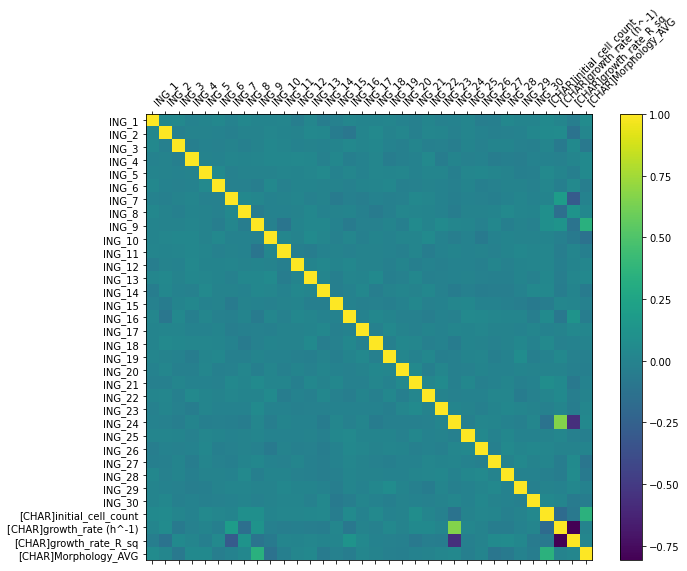

In [16]:
# plot correlation matrix

plt.figure(figsize=(10, 8)) 
plt.matshow(data.iloc[:,5:].corr(), fignum=1)
plt.colorbar()

plt.xticks(ticks=np.arange(len(data.iloc[:,5:].columns)), labels=data.iloc[:,5:].columns, rotation=45, ha="left")
plt.yticks(ticks=np.arange(len(data.iloc[:,5:].columns)), labels=data.iloc[:,5:].columns);

The matrix is unfortunately a little bit too large to extract much meaningful, but we can see that there is a lot going on in the bottom right corner.

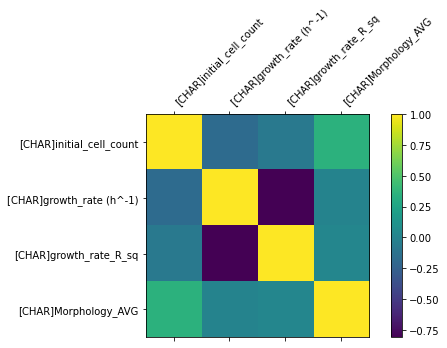

In [17]:
# plot bottom right corner of correlation matrix 

plt.figure(figsize=(8, 4)) 
plt.matshow(data.iloc[:,35:].corr(), fignum=1)
plt.colorbar()

plt.xticks(ticks=np.arange(len(data.iloc[:,35:].columns)), labels=data.iloc[:,35:].columns, rotation=45, ha="left")
plt.yticks(ticks=np.arange(len(data.iloc[:,35:].columns)), labels=data.iloc[:,35:].columns);

From this we can see three things: first, the morphology is correlated with the initial cell count. This could introduce a bias in our ingredient analysis, as the initial cell count is most likely random, i.e., independent of the ingredients. I do understand too little about the cell biology, but one could try to factor out the effect of the initial cell count on the morphology (as well as the smaller effect on the growth rate). Second, there is a strong negative correlation between the R squared value of the growth model compared to the growth rate. And third, there is a positive correlation between the growth rate and the morphology, indicating that we can find some combination of variables that might increase both parameters at the same time.

Since we are mainly interested in the significance of the different ingredients on the growth rate and the morphology, let us display the correlations for these two parameters: 

In [18]:
# print correlation matrix entries for growth rate and morphology
print(data.iloc[:,5:].corr()[['[CHAR]growth_rate (h^-1)', '[CHAR]Morphology_AVG']].applymap(lambda x: f"{x:.2f}"))

                         [CHAR]growth_rate (h^-1) [CHAR]Morphology_AVG
ING_1                                        0.02                 0.07
ING_2                                        0.06                 0.02
ING_3                                       -0.06                -0.08
ING_4                                       -0.01                 0.05
ING_5                                        0.01                 0.05
ING_6                                       -0.03                -0.03
ING_7                                        0.19                -0.01
ING_8                                       -0.15                 0.03
ING_9                                        0.12                 0.34
ING_10                                      -0.02                -0.13
ING_11                                      -0.04                -0.03
ING_12                                      -0.03                 0.02
ING_13                                      -0.03                 0.04
ING_14

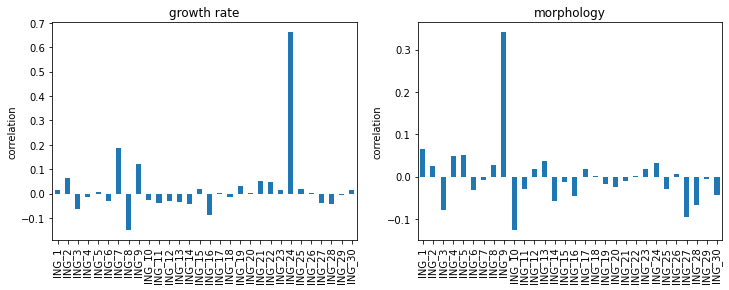

In [19]:
# plot correlation matrix entries for growth rate and morphology
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
data.iloc[:,5:].corr()['[CHAR]growth_rate (h^-1)'][:30].plot.bar()
plt.title("growth rate")
plt.ylabel("correlation");

plt.subplot(1,2,2)
data.iloc[:,5:].corr()['[CHAR]Morphology_AVG'][:30].plot.bar()
plt.title("morphology")
plt.ylabel("correlation");

It appears that the ingredients `ING_7`, `ING_8`, `ING_9` and `ING_24` are the most correlated with the growth rate. Moreover, `ING_9`, `ING_10` and `ING_27` seem to be the most correlated with the morphology. Note that some ingredients such as `ING_8` can have different correlations with the two target parameters: a positive correlation with the growth rate and a negative correlation with the morphology. This hints towards that an increase of the concentration of this ingredient might increase the growth rate but decrease the morphology. This together with possible correlations between the ingredients indicates that the optimization problem is complex and non-linear. Let's illustrate the correlation: 

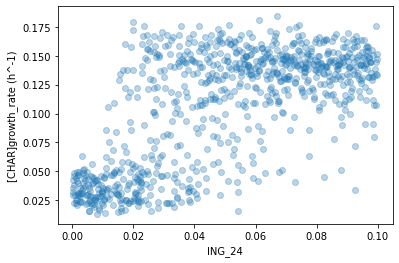

In [20]:
plt.plot(data['ING_24'], data['[CHAR]growth_rate (h^-1)'], 'o', alpha=0.3, color='C0')
plt.xlabel('ING_24')
plt.ylabel('[CHAR]growth_rate (h^-1)');

Next, look for individual parameters that are related to the two target parameters by analyzing the mutual information. Similar to the correlation, the mutual information is a measure of the mutual dependence between two variables. In contrast to the correlation coefficients, the mutual information is more general and not limited to linear dependencies. It determines how different the joint distribution of two variables is from the product of their marginal distributions. 

In [21]:
from sklearn.feature_selection import mutual_info_regression

# compare the mutual information of the ingredient concentrations to the growth rate
mutual_info_growth = mutual_info_regression(data.iloc[:,5:35], data['[CHAR]growth_rate (h^-1)'])

print('Mutual information for growth rate:')

# print all ingredients for which the mutual information is larger than zero, i.e., there is some relative dependence
for i, m in enumerate(mutual_info_growth):
    if m > 0: 
        print(data.keys()[5:35][i], round(m,3))

Mutual information for growth rate:
ING_5 0.002
ING_9 0.049
ING_10 0.022
ING_15 0.081
ING_24 0.327
ING_30 0.0


In [22]:
# compare the mutual information of the ingredient concentrations to the morphology
mutual_info_morph = mutual_info_regression(data.iloc[:,5:35], data['[CHAR]Morphology_AVG'])

print('Mutual information for morphology:')

# print all ingredients for which the mutual information is larger than zero, i.e., there is some relative dependence
for i, m in enumerate(mutual_info_morph):
    if m > 0: 
        print(data.keys()[5:35][i], round(m,3))

Mutual information for morphology:
ING_1 0.016
ING_2 0.038
ING_3 0.033
ING_8 0.011
ING_9 0.064
ING_10 0.041
ING_11 0.026
ING_14 0.003
ING_16 0.008
ING_22 0.039
ING_24 0.001


We already deduced some of the dependencies from the correlation matrix above, for example that `ING_9` and `ING_24` have a strong impact on the growth rate. However, the mutual information for `ING_8` is zero although we found a large correlation to the growth rate. 

Unfortunately, we cannot use the mutual information to determine which ingredients are relevant for both growth rate and morphology at the same time. Therefore, we will instead use recursive feature elimination with cross-validation (RFECV). This algorithm is based on an estimator that assigns importance weights to a given set of input features. (We will later discuss what kind of estimators we can use for that.) The recursive feature eliminator selects relevant features by recursively considering smaller sets of features. First, the estimator is trained on the initial set of 30 features and the importance of each feature is determined. Then, the least important feature is eliminated. This procedure is repeated until only no feature is left to be used by the estimator. At each step the mean cross-validation score of the data is computed based on the estimator trained on the current set of features. The optimal number of features is then given by the step that leads to the minimal mean cross-validation score.  

For the estimator, we can employ a random forest estimator. This is an ensemble method that is composed of a collection of decision trees to make predictions. Each decision tree is a flowchart-like model where data is split based on features to form branches, ultimately leading to 'leaf' nodes that represent predicted outcomes. In a random forest, multiple decision trees are trained on different subsets of the data and features; then, their predictions are combined to improve accuracy and reduce the risk of overfitting compared to using a single tree.

Let us start by fitting a random forest estimator based on all features.This requires that we first split the data into train and test data, and do a grid search to find the best hyperparameters, such as the maximum depth of the decision trees in the estimator.

In [23]:
from sklearn.model_selection import train_test_split

# predictor variables given by ingredient concentrations
X = data.iloc[:,5:35]
# target variables are the growth rate and the morphology
Y = data[['[CHAR]growth_rate (h^-1)', '[CHAR]Morphology_AVG']]

# split data into train and test data to avoid overfitting
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, random_state=1
)

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# set random forest estimator
model = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)

# perform search over hyperparameters of the estimator, e.g., the maximum depth of the decision trees
parameters = {'max_depth': [1,3,5,7,10],
              'min_samples_split': [2,3,5,7,10,15],
              'min_samples_leaf': [1,3,5,7,10,15]
             }

model = GridSearchCV(model, parameters)
model.fit(X_train, y_train)

# print score on training and test data
print(f"model score on training data: {model.score(X_train, y_train)}")
print(f"model score on testing data: {model.score(X_test, y_test)}")

model score on training data: 0.4916741440086473
model score on testing data: 0.4446589712642421


In [25]:
# print best hyperparameters
model.best_params_

{'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 3}

Now that we know the best hyperparameters for our estimator, we can illustrate how it assigns importance weights to features. In a decision tree the feature importance is given by the mean decrease in impurity, i.e., the number of times a feature is used to split a leaf node, weighted by the number of samples it splits. We can already depict the feature importance for our fitted estimator using all features. Note that the mean decrease in impurity can be misleading for high cardinality features, where we alternatively could use the permutation importance.   

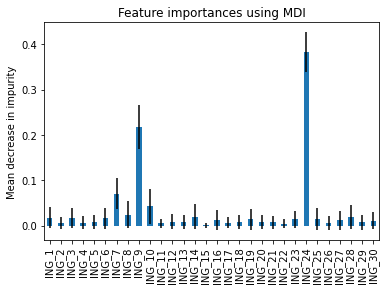

In [26]:
# Set up the model according to optimal hyperparameters
model = RandomForestRegressor(n_estimators=100, random_state=1, max_depth=5, min_samples_leaf=10, min_samples_split=2)
model.fit(X_train, y_train)

# extract feature importances and compute standard deviation across all trees in ensemble
importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)

forest_importances = pd.Series(importances, index=raw_data.iloc[:,5:35].columns)

# bar plot the importance for each feature
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity");

From this we can see that the features `ING_9` and `ING_24` are the most important ingredients used to perform splits in the random forest to determine the growth rate as well as the morphology. We saw these features already in the above separate analyses. Now let us run the recursive feature elimination algorithm as explained above. Note that this algorithm of course depends on our chosen estimator. The same algorithm might lead to different results for e.g. a neural network: 

In [28]:
from sklearn.feature_selection import RFECV

selector = RFECV(model, cv=5)
selector = selector.fit(X, Y)

# print optimal number of features
selected_features = data.iloc[:,5:35].columns[selector.support_]
print("Selected", selector.n_features_, "features:", selected_features.tolist())

Selected 9 features: ['ING_1', 'ING_3', 'ING_7', 'ING_8', 'ING_9', 'ING_10', 'ING_14', 'ING_24', 'ING_28']


The optimal number of features that leads to the smalles mean score is 9, which again includes `ING_9` and `ING_24` we saw above. Even though we do not use all of the available features, we can predict growth rate and morphology similar to using all 30 features as above:

In [29]:
print("score of reduced model with", selector.n_features_, f"features: {model.score(X_test, y_test)}")

score of reduced model with 9 features: 0.4450150207726787


Finally, plot how the test accuracy of the estimator changes if we increase the number of features: 

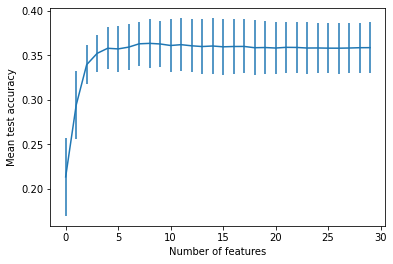

In [30]:
# cross-validation scores of the RFECV algorithm
cv_results = pd.DataFrame(selector.cv_results_)
plt.xlabel("Number of features")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=np.arange(30),
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
);

Using only very few features leads to a bad accuracy of the estimator. Increasing the number of features improves the performance. However, for more than 9 features there is a plateau, i.e., the accuracy does not further improve. This indicates that the remaining 21 features have no or only only very little impact on the cell growth and morphology. Using only the 9 relevant features reduces the computational complexity of the optimization problem and avoids overfitting, together with the further advantages discussed in the task description.  

## Next set of formulations

Next, come up with an approach to determine the next of formulations to test in order to maximize growth and morphology while minimizing the ingredient cost. Here, we focus on outlining an approach instead of the detailed technical implementation. 

### Summary of the approach

We start by reducing the multi-objective optimization problem into a single objective using scalarization. The resulting single objective is quite noisy, therefore we choose to use Bayesian optimization, which amounts to iteratively fitting Gaussian Processes to determine the next sets of formulations. If I had more time this approach could be extended to multiple objectives, which allows more efficient exploration and exploitation as well as a better understanding of the trade-offs between different objectives. If we increase the number of relevant ingredients or could somehow reduce the noise, e.g., by taking effects of the initial number of cells into account, we could employ more complex surrogate models to predict the objectives together with Genetic algorithms that are advantageous when dealing with high-dimensional, complex problems.

### Approach

Start by importing the cost and adding a corresponding column to our table.

In [31]:
# import and view ingredient costs
ing_costs = pd.read_excel('.\data/ing_costs.xlsx', sheet_name='Sheet1')
ing_costs.head(10)

,Ingredient,$/g
0,ING_1,0.010
1,ING_2,0.010
2,ING_3,0.010
3,ING_4,0.010
4,ING_5,0.010
5,ING_6,323.000
6,ING_7,205.975
7,ING_8,91.200
8,ING_9,33.000
9,ING_10,50000.000


In [32]:
# define a function to determine cost for given array of concentrations
# returns the cost in $/L
def ingredient_cost(ing_array):
    return (ing_array * ing_costs['$/g']).sum()

# add cost column to data
data['Cost[$/L]'] =  [ingredient_cost(data.iloc[i][5:35].to_numpy()) for i,_ in enumerate(data['experimental_condition_id'])]

We need to solve a multi-objective optimization problem, where we want to maximize growth rate and morphology while minimizing the number of costs. Simultaneous optimization of multiple objectives results in a set of trade-off solutions which are referred to as the Pareto front. See for example the figure below. If we only wanted to optimize the growth rate and the morphology, the Pareto front would be in the top right corner. We could then select a prefered solution from the set of optimal trade-offs. However, in our case we additionally want to minimize the cost, which is illustrated by the colors in the figure below. 

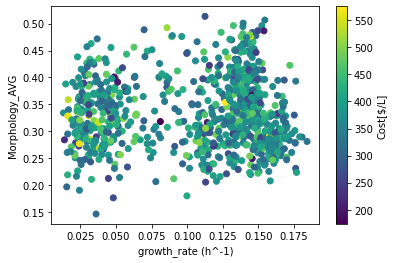

In [33]:
# scatter plot growth rate vs. morphology, the color of the points indicates the cost
plt.scatter(data['[CHAR]growth_rate (h^-1)'], data['[CHAR]Morphology_AVG'], c=data['Cost[$/L]'])
cbar = plt.colorbar()
cbar.set_label('Cost[$/L]') 
plt.xlabel('growth_rate (h^-1)')
plt.ylabel('Morphology_AVG');

One way to address multi-objective optimization problems is to reduce them to a single-objective optimization problem using a set of methods called scalarization. The most simple of these methods is linear scalarization, where we construct a single objective by the weighted sum over all objectives $f_i(x)$: 

\begin{align}
    \min_{x \in X} \sum_i \omega_i f_i(x)\,.
\end{align}

In the above 3D plot of the three objective functions the weighted sum corresponds to a linear line that might cross the Pareto front depending on the chosen weights. 

In the figure below we have displayed the weighted sum of our three objectives as a function of one ingredient. (Note that we have set the growth rate and the morphology negative so that the goal is minimizing instead of maximizing them.) Now, we can apply single-objective optimization techniques to the weighted sum. If we find the optimal value for each combination of weights, we can determine the non-convex part of the Pareto surface. There are also more advanced techniques such as hypervolume/Chebyshev scalarization that also allow to determine convex optimal solutions. 

Text(0, 0.5, 'Weighted sum')

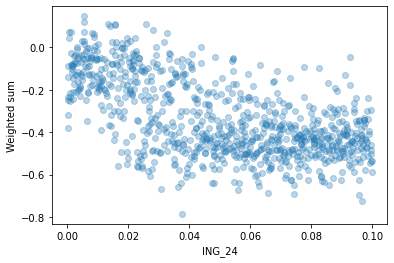

In [34]:
# arbitrarily chosen weights
# note they are set to negative values for the growth rate and morphology, as these need to be maximized
weights = [-1/3, -1/3, 1/3]

# weighted sum
# note that the objectives are normalized just by their mean values, there are better normalizations in the literature 
weighted_sum =  sum([weights[i] * data[c]/data[c].mean() for i,c in enumerate(['[CHAR]growth_rate (h^-1)', '[CHAR]Morphology_AVG', 'Cost[$/L]'])])

plt.plot(data['ING_24'], weighted_sum, 'o', alpha=0.3)
plt.xlabel('ING_24')
plt.ylabel('Weighted sum')

In our problem, we do not have an analytical expression of the objective function, because we do not have analytical expressions to evaluate the growth rate and morphology for given ingredient concentrations. (In contrast, we can analytically compute the cost which depends linearly on the ingredients.) To find the next set of formulations, we therefore need to employ surrogate models to approximate the objective function and then use an optimization strategy to find a set of ingredients. Unfortunately, in our case the data is quite noisy. One reason for that could be that growth-rate and morphology depend on the (random) initial cell count. For such noisy data, one appropiate surrogate model could be a Gaussian Process. 


A Gaussian Process is a probabilistic model used for non-parametric function modeling, where a function $f(x)$ is assumed to follow a Gaussian distribution across all possible points $x$ in its input space. Instead of specifying a fixed form for $f(x)$, a Gaussian Process defines a distribution over functions by modeling the correlations between function values at different input points using a kernel. This means a GP can provide a smooth estimate for the function over the entire input space, along with uncertainty estimates. To illustrate this we fit a Gaussian Process below and display its mean and standard deviation for one variable (while the other ones are kept constant).

In [35]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, Matern, ConstantKernel                      

# choose a Matern kernel plus a WhiteKernel to model the noise
# the hyperparameters of the kernel are also estimated during the fit
kernel = Matern() + ConstantKernel() * WhiteKernel()

# fit Gaussian Process
model_gp = GaussianProcessRegressor(random_state=1, alpha=1e-8, kernel=kernel)
model_gp.fit(data[selected_features], weighted_sum);

print("Score:", round(model_gp.score(data[selected_features], weighted_sum),2))

Score: 0.78


In [38]:
# illustrate the Gaussian Process, we vary only one ingredient 
# and keep the other ingredients at their mean values

# start by filling and attay with 100 times the mean value of the first of the nine relevant ingredients
X = data[selected_features]
predictor_array = (X.mean()[0] * np.ones(100))[None]

# ingredient not set to constant mean
not_const_idx = 2

for i in range(1,9):
    if i == not_const_idx:
        # non-constant ingredient is given by linear array between the min and max values 
        ING_array = np.linspace(X.min()[i], X.max()[i], 100)
        predictor_array = np.append(predictor_array, ING_array[None], axis=0)
    else: 
        predictor_array = np.append(predictor_array, (X.mean()[i] * np.ones(100))[None], axis=0)

In [39]:
# based on the above array determine sample from the trained Gaussian Process
# (remember that the training data was transformed to mean 0 and std 1)
gp_samples = model_gp.sample_y(predictor_array.T, n_samples=20000)

# determine the mean and the standard deviation of the samples
gp_target_mean = np.mean([gp_samples[i].T for i in range(len(gp_samples))], 1)
gp_target_std = np.std([gp_samples[i].T for i in range(len(gp_samples))], 1)

C:\Users\lenbr\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(


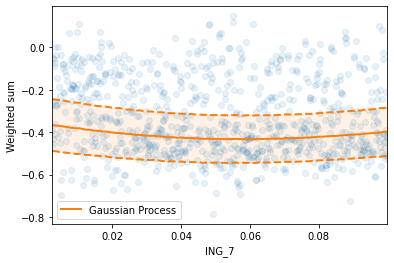

In [40]:
c = X.columns[not_const_idx]

# plot weighted sum
plt.plot(data[c], weighted_sum, 'o', alpha=0.1)

# plot mean and standard deviation of the Gaussian Process
plt.plot(predictor_array[not_const_idx], gp_target_mean, lw=2, color='C1', label='Gaussian Process')
plt.plot(predictor_array[not_const_idx], gp_target_mean + gp_target_std, lw=2, ls='dashed', color='C1')
plt.plot(predictor_array[not_const_idx], gp_target_mean - gp_target_std, lw=2, ls='dashed', color='C1')

plt.fill_between(predictor_array[not_const_idx], gp_target_mean - gp_target_std, gp_target_mean + gp_target_std, alpha=0.1, color='C1')

plt.legend()
plt.xlabel(c)
plt.ylabel('Weighted sum')
plt.xlim([data[c].min(), data[c].max()]);

We can use the Gaussian Process to guide the selection of new formulations to test using the data from the previously evaluated experiments in an approach called Bayesian optimization. This method allows to optimize expensive, black-box functions. We start by defining an acquisition function, such as the upper confidence bound, which is given by the mean $\mu(x)$ and the standard deviation $\sigma(x)$ of the Gaussian Process: 

\begin{align}
    a(x) = \mu(x)+\kappa \sigma(x)\,,
\end{align}

where the parameter $\kappa$ guides the tradeoff between exploration (sampling uncertain regions) and exploitation (sampling regions likely to yield high values). You can see the upper confidence bound for the above example in the figure below:

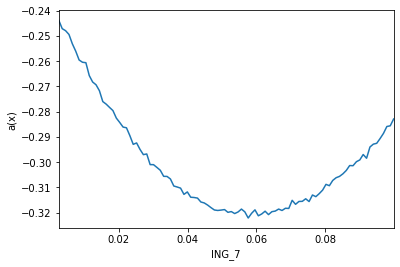

In [41]:
# select kappa
kappa = 1

# determine upper confidence bound
ucb = gp_target_mean + kappa * gp_target_std

plt.plot(predictor_array[not_const_idx], ucb)

plt.xlabel(c)
plt.ylabel('a(x)')
plt.xlim([data[c].min(), data[c].max()]);

One possible combination of ingredients to test next is then determined as the minimum of the aquisition function. Here, that would probably mean a concentration of `ING_7` around $0.06\,$g/L. Afterwards, the weights of the scalarization function are changed and the procedure is repeated to find multiple optimal solutions. Some of these solutions can then be chosen based on external preferences (e.g. preferring a lower cost) and the chosen formulations can then be tested. After the information from the new experiments is available, the Gaussian Process as well as the acquisition function are updated and different solutions are found. There are other acquisition functions, which might be more suitable for our problem here.

Bayesian optimization can be extended to multi-objective optimization problems. There, one Gaussian Process is typically used to model each objective function. Then, specially designed acquisition functions are used to combine the different objectives and to directly find the Pareto front. The tailored acquisition functions allow to explore and exploit across objectives efficiently, possibly resulting in faster convergence. In contrast, scalarization might miss part of the pareto front. Moreover, in scalarization we have to be sure of our preferences between the three objectives beforehand by choosing on how to sample the weights, while the extension of Bayesian optimization to multiple objectives allows to better understand the trade-offs across the Pareto front.

Bayesian optimization usually relies on Gaussian Processes which do not scale well to high dimensions. So, if the number of relevant ingredients increases they might lead to a poor description. Moreover, if it is possible to reduce the noise in the data, for example by taking effects of the initial cell count into account, other surrogate models might lead to a better description of the objective functions. Here, it is possible to again use Random Forest estimators or even artifical neural networks. Both of these scale better to higher dimensions than Gaussian Processes. Random Forests are easily interpretable (as we saw above) and are not very sensitive to noise and outliers. However, their predictions are not continuous. Artifical neural networks (or multilayer perceptrons) are non-parametric models motivated by the structure of the human brain. They consist of a net of connected layers refered to as neurons which are structured in different layers. Each neutron receives input from the neurons in the previous layer, computes an output and and passes it to the next layer. They are capable of learning complex high-dimensional relationships. Moreover, they are differntiable, allowing to use derivative information for optimization. However, they do require lots of data, are prone to overfitting and can lead to noisy predictions.  

With such an improved surrogate function, we can employ Genetic Algorithms to tackle multi-objective optimization problems effectively. Genetic Algorithms are a class of evolutionary algorithms that operate on a population of candidate solutions, which evolve over successive generations. The process begins with an initial population of random individuals, each evaluated using the surrogate model to assign a score. These individuals are then ranked based on their scores, and those with higher ranks are selected for reproduction. Through recombination, the selected individuals create the next generation of candidates. To enhance exploration of the objective space, it is essential to introduce mutations in the new individuals. This iterative process continues over multiple generations.

Genetic Algorithms have several advantages: they scale well to high-dimensional problems, can efficiently navigate complex search spaces, and are adept at avoiding local minima. However, the choice of parameters (such as population size, mutation rate, and selection pressure) can significantly impact their performance and may require careful tuning. While Genetic Algorithms are good at exploring the search space, they might converge slowly to an optimal solution compared to more specialized techniques like Bayesian optimization.